# QTradeSystematic - ML-Factor End-to-End Flow
End-to-end: data load -> feature engineering -> XGB model -> backtest -> CSV + pyfolio tearsheet export.


In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

from datetime import date, datetime
from decimal import Decimal
from functools import partial
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import yaml

from qts.config.builder import Config
from qts.core.registry import Registry
from qts.orchestration.runtime import build_data_manager
from qts.research.backtest.base import BacktestConfig
from qts.research.backtest.engines.vectorbtpro_engine import VectorBTProEngine
from qts.research.backtest.pyfolio_adapter import (
    positions_frame,
    returns_series,
    transactions_frame,
)
from qts.research.backtest.tearsheet import save_tearsheet
from qts.research.features.pipeline import FeaturePipeline
from qts.utils.export import export_portfolio_snapshots, export_trade_log
from qts.utils.paths import backtest_exports_dir, tearsheet_dir

print("Imports OK")


Imports OK


## Step 1 - Load YAML config


In [2]:
CONFIG_PATH = Path("../configs/strategies/ml_factor/vn100_ml_example.yaml")

resolved = Config.build(str(CONFIG_PATH))
config: BacktestConfig = resolved.raw

symbols = [
    *config.universe.stock,
    *config.universe.vn_stock,
    *config.universe.vn_warrant,
    *config.universe.vn_futures,
    *config.universe.crypto,
    *config.universe.crypto_futures,
]

print(f"Workflow       : {config.workflow}")
print(f"Universe       : {symbols}")
print(f"Date range     : {config.start_date} -> {config.end_date}")
print(f"Test start     : {config.test_start_date}")
print(f"Initial capital: {config.initial_capital:,}")
print(f"Engine         : {config.backtest_engine}")
print(f"Benchmark      : {config.benchmark}")


Workflow       : research
Universe       : ['VN:ACB', 'VN:CTS', 'VN:DBC', 'VN:SHB', 'VN:VCG', 'VN:VIX', 'VN:VND', 'VN:DCM', 'VN:DGC', 'VN:ANV', 'VN:BID', 'VN:BMP', 'VN:BSI', 'VN:BVH', 'VN:CII', 'VN:CMG', 'VN:CTD', 'VN:CTG', 'VN:DIG', 'VN:DPM', 'VN:DXG', 'VN:EIB', 'VN:FPT', 'VN:GAS', 'VN:GMD', 'VN:HAG', 'VN:HCM', 'VN:HDC', 'VN:HDG', 'VN:HPG', 'VN:HSG', 'VN:HT1', 'VN:IMP', 'VN:KBC', 'VN:KDC', 'VN:KDH', 'VN:MBB', 'VN:MSN', 'VN:MWG', 'VN:NKG', 'VN:NLG', 'VN:NT2', 'VN:PAN', 'VN:PDR', 'VN:PHR', 'VN:PNJ', 'VN:PPC', 'VN:PTB', 'VN:PVD', 'VN:PVT', 'VN:REE', 'VN:SBT', 'VN:SJS', 'VN:SSI', 'VN:STB', 'VN:TLG', 'VN:VCB', 'VN:VHC', 'VN:VIC', 'VN:VNM', 'VN:VSC', 'VN:HHV', 'VN:TCH', 'VN:PC1', 'VN:SAB', 'VN:FTS', 'VN:VIB', 'VN:VJC', 'VN:PLX', 'VN:DGW', 'VN:SCS', 'VN:VCI', 'VN:BWE', 'VN:VPB', 'VN:LPB', 'VN:VPI', 'VN:VRE', 'VN:KOS', 'VN:CTR', 'VN:HDB', 'VN:GEX', 'VN:BCM', 'VN:POW', 'VN:FRT', 'VN:VHM', 'VN:GVR', 'VN:TPB', 'VN:TCB', 'VN:EVF', 'VN:SZC', 'VN:VGC', 'VN:OCB', 'VN:MSB', 'VN:DXS', 'VN:SSB', 'VN:SI

## Step 2 - Fetch OHLCV from DuckDB


In [3]:
data_manager = build_data_manager(resolved)

raw: pl.DataFrame = await data_manager.get_ohlcv(
    symbols=symbols,
    start=config.start_date,
    end=config.end_date,
)

print(f"Rows: {len(raw):,}  |  Symbols: {raw['symbol'].n_unique()}  |  Columns: {raw.columns}")
raw.head(5)


Rows: 190,874  |  Symbols: 100  |  Columns: ['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']


date,symbol,open,high,low,close,volume
date,str,f64,f64,f64,f64,f64
2018-01-02,"""VN:ACB""",6.49276,6.826172,6.457664,6.808624,3.657426e6
2018-01-02,"""VN:ANV""",3.850372,3.90264,3.76326,3.83295,493150.0
2018-01-02,"""VN:BID""",13.910275,14.728527,13.746625,14.728527,2.90377e6
2018-01-02,"""VN:BMP""",38.707,39.973,37.984,39.702,562680.0
2018-01-02,"""VN:BSI""",7.525532,7.9824393,6.987994,7.9555624,223660.0


## Step 3 - Feature Engineering


In [4]:
feature_pipeline: FeaturePipeline = resolved.feature_pipeline
featured: pl.DataFrame = feature_pipeline.fit_transform(raw)

print(f"Featured shape : {featured.shape}")
print(f"Feature columns: {[col for col in featured.columns if col not in raw.columns]}")
featured.head(3)


Featured shape : (190874, 11)
Feature columns: ['close_qsmom_21_50_50', 'rsi_14', 'roc_21', 'forward_return_12']


date,symbol,open,high,low,close,volume,close_qsmom_21_50_50,rsi_14,roc_21,forward_return_12
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
2018-01-02,"""VN:ACB""",6.49276,6.826172,6.457664,6.808624,3.657426e6,null,null,null,0.018041
2018-01-03,"""VN:ACB""",6.808624,6.861268,6.66824,6.791076,5.056543e6,null,null,null,0.020672
2018-01-04,"""VN:ACB""",6.791076,6.826172,6.738432,6.808624,6.365641e6,null,null,null,0.036082


## Step 4 - Feature exploration


In [5]:
predictor_cols = config.strategy.params["predictor_cols"]
target_col = config.strategy.params["target_col"]

print(f"Predictors : {predictor_cols}")
print(f"Target     : {target_col}")

null_rates = {
    col: featured[col].null_count() / len(featured)
    for col in predictor_cols + [target_col]
}
print("\nNull rates:")
for col, rate in null_rates.items():
    print(f"  {col:40s}  {rate:.1%}")

featured.select(predictor_cols).describe()


Predictors : ['rsi_14', 'roc_21']
Target     : forward_return_12

Null rates:
  rsi_14                                    0.7%
  roc_21                                    1.1%
  forward_return_12                         0.6%


statistic,rsi_14,roc_21
str,f64,f64
"""count""",189574.0,188774.0
"""null_count""",1300.0,2100.0
"""mean""",51.500869,0.017192
"""std""",12.933696,0.123403
"""min""",2.041441,-0.730942
"""25%""",42.789897,-0.047944
"""50%""",51.186207,0.0074
"""75%""",60.092685,0.074133
"""max""",98.697715,2.741806


In [6]:
import numpy as np

corr = featured.select(predictor_cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(predictor_cols)))
ax.set_yticks(range(len(predictor_cols)))
ax.set_xticklabels(predictor_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(predictor_cols, fontsize=9)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## Step 5 - Build XGB model + MLFactorStrategy


In [7]:
from qts.research.strategies.ml_factor.classification import MLFactorStrategy
from qts.research.strategies.ml_factor.classifications import XGBClassifierModel

model_params = config.strategy.params.get("model", {}).get("params", {})
model = XGBClassifierModel(task="classification", **model_params)

portfolio_cfg = config.portfolio_construction
portfolio_func = None
if portfolio_cfg is not None:
    portfolio_func = partial(
        Registry.get_portfolio_constructor(portfolio_cfg.name),
        **portfolio_cfg.params,
    )

strategy = MLFactorStrategy(
    predictor_cols=predictor_cols,
    target_col=target_col,
    model=model,
    portfolio_func=portfolio_func,
    task=config.strategy.params.get("task", "classification"),
    rebalance_period=config.strategy.params.get("rebalance_period", 21),
)
print(f"Strategy: {strategy}")


Strategy: <qts.research.strategies.ml_factor.classification.MLFactorStrategy object at 0x11ecb1090>


## Step 6 - Run backtest (VectorBTProEngine)


In [8]:
engine = VectorBTProEngine()

result = engine.run(
    strategy=strategy,
    data=featured,
    config=config,
    pipeline=feature_pipeline,
    ohlcv=raw,
)

print("\n=== In-sample metrics ===")
for key, value in result.metrics.items():
    print(f"  {key:20s}: {value:.4f}")



=== In-sample metrics ===
  sharpe              : 1.0807
  sortino             : 1.3117
  cagr                : 0.2589
  max_drawdown        : 0.5021
  win_rate            : 0.4682


## Step 7 - In-sample vs out-of-sample split check


In [9]:
oos_start = pd.Timestamp(config.test_start_date).tz_localize("UTC")
rets_series = returns_series(result)

is_rets = rets_series[rets_series.index < oos_start]
oos_rets = rets_series[rets_series.index >= oos_start]

def annualised_sharpe(series: pd.Series) -> float:
    if series.empty or series.std() == 0:
        return 0.0
    return (series.mean() / series.std()) * (252 ** 0.5)

def period_label(series: pd.Series) -> str:
    if series.empty:
        return "empty"
    return f"{series.index[0].date()} -> {series.index[-1].date()}"

print(f"IS  period : {period_label(is_rets)}  |  Sharpe: {annualised_sharpe(is_rets):.3f}")
print(f"OOS period : {period_label(oos_rets)}  |  Sharpe: {annualised_sharpe(oos_rets):.3f}")

fig, ax = plt.subplots(figsize=(12, 4))
equity = result.equity_curve.to_pandas()
equity["date"] = pd.to_datetime(equity["date"])
ax.plot(
    equity["date"],
    equity["equity"] / equity["equity"].iloc[0],
    label="Strategy",
    linewidth=1.5,
)
if config.test_start_date:
    ax.axvline(
        pd.Timestamp(config.test_start_date),
        color="red",
        linestyle="--",
        alpha=0.7,
        label="OOS start",
    )
ax.set_title("Equity curve (normalised)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


IS  period : 2018-01-02 -> 2023-12-29  |  Sharpe: 0.969
OOS period : 2024-01-02 -> 2025-12-31  |  Sharpe: 1.509


## Step 8 - Save CSV outputs


In [10]:
run_id = f"{result.engine_name}_{datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}"
exports_dir = backtest_exports_dir()

tl_path = exports_dir / f"{run_id}_trade_log.csv"
snp_path = exports_dir / f"{run_id}_snapshots.csv"

export_trade_log(result, tl_path)
export_portfolio_snapshots(result, snp_path)

print(f"Trade log  -> {tl_path}  ({result.trade_log.shape[0]} rows)")
print(f"Snapshots  -> {snp_path}  ({result.portfolio_snapshots.shape[0]} rows)")
result.trade_log.head(5)


Trade log  -> /Users/s2997726/.qts/exports/backtest/vectorbt_20260521T063052Z_trade_log.csv  (0 rows)
Snapshots  -> /Users/s2997726/.qts/exports/backtest/vectorbt_20260521T063052Z_snapshots.csv  (0 rows)


ticker,entry_time,exit_time,start_price,end_price,quantity,profit_pct,fee,side
str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,str


## Step 9 - Generate pyfolio tearsheet


In [11]:
benchmark_rets = None
if config.benchmark:
    from qts.orchestration.flow import _fetch_benchmark_returns

    benchmark_rets = _fetch_benchmark_returns(
        config.benchmark,
        config.start_date,
        config.end_date,
        data_manager,
    )
    if benchmark_rets is not None:
        print(f"Benchmark loaded: {len(benchmark_rets)} days of {config.benchmark}")
    else:
        print(f"Benchmark {config.benchmark} not found in DB - running without")


Benchmark VN:VNINDEX not found in DB - running without


In [12]:
pdf_path = save_tearsheet(
    result=result,
    out_dir=tearsheet_dir(),
    run_id=run_id,
    benchmark_rets=benchmark_rets,
)

if pdf_path:
    print(f"Tearsheet PDF -> {pdf_path}  ({pdf_path.stat().st_size / 1024:.1f} KB)")
else:
    print("Tearsheet skipped (pyfolio not installed)")


Start date,2018-01-02
End date,2025-12-31
Total months,95
,Backtest
Annual return,25.872%
Cumulative returns,520.44%
Annual volatility,23.968%
Sharpe ratio,1.08
Calmar ratio,0.52
Stability,0.88
Max drawdown,-50.206%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,50.21,2022-02-11,2022-11-15,2024-05-17,591
1,21.81,2021-06-03,2021-10-01,2022-02-11,182
2,18.53,2020-03-05,2020-03-30,2020-04-10,27
3,17.43,2025-08-21,2025-12-26,NaT,NaN
4,17.01,2020-06-08,2020-07-27,2020-08-27,59


Stress Events,mean,min,max
New Normal,0.00%,0.00%,0.00%
Covid,0.13%,-8.97%,6.30%


Tearsheet PDF -> /Users/s2997726/.qts/exports/backtest/tearsheets/vectorbt_20260521T063052Z_tearsheet.pdf  (196.9 KB)


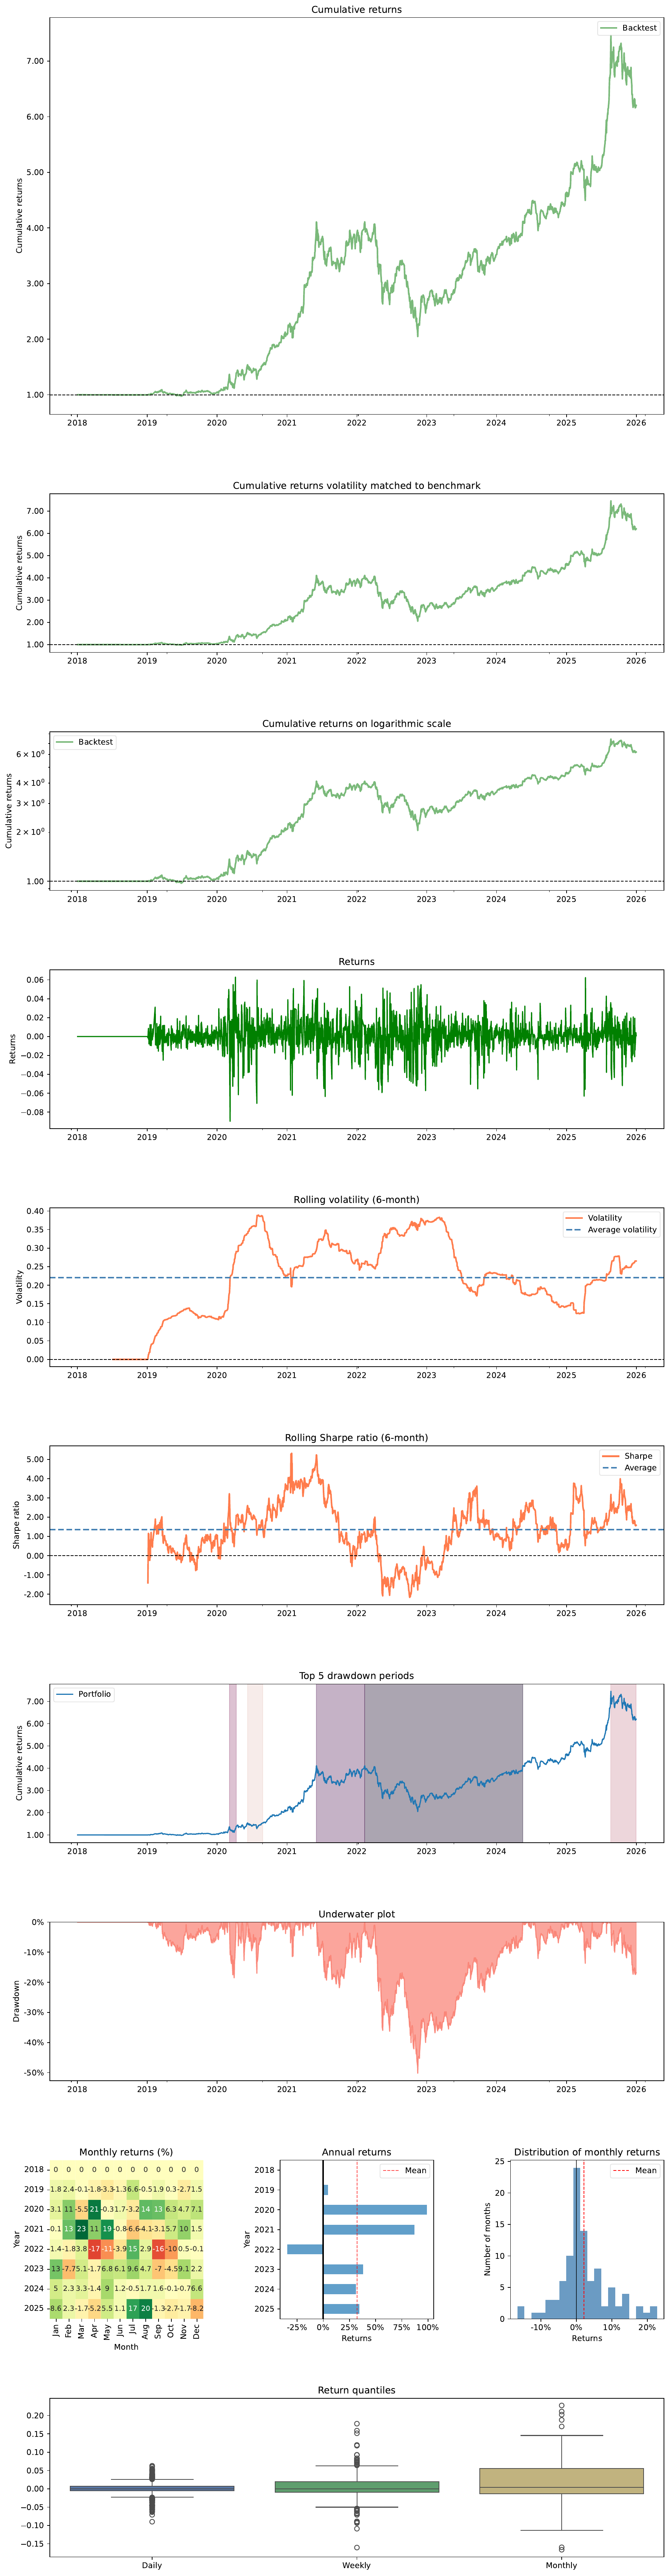

In [13]:
if pdf_path and pdf_path.exists():
    import shutil
    import subprocess

    if shutil.which("pdftoppm"):
        png_out = pdf_path.with_suffix("")
        subprocess.run(
            ["pdftoppm", "-r", "150", "-png", "-l", "1", str(pdf_path), str(png_out)],
            check=False,
        )
        candidates = list(pdf_path.parent.glob(f"{run_id}_tearsheet-*.png"))
        if candidates:
            from IPython.display import Image, display

            display(Image(str(candidates[0])))
        else:
            print(f"Open the PDF manually: {pdf_path}")
    else:
        print(f"Install poppler for inline display. PDF at: {pdf_path}")


## Summary

| Output | Path |
|--------|------|
| Trade log CSV | `~/.qts/exports/backtest/{run_id}_trade_log.csv` |
| Snapshots CSV | `~/.qts/exports/backtest/{run_id}_snapshots.csv` |
| Tearsheet PDF | `~/.qts/exports/backtest/tearsheets/{run_id}_tearsheet.pdf` |
